# Loading NAIP Imagery for GIS & Vegetation Modeling
The National Agriculture Imagery Program (NAIP) provides 4-band (RGB + Near-Infrared) 0.6m–1m aerial imagery across the contiguous U.S. during growing seasons.

This notebook demonstrates how to:
- Search a SpatioTemporal Asset Catalog (STAC) for arial imagery
- Visualize arial imagery
- Calculate a Normalized difference vegetation index ([NDVI](https://en.wikipedia.org/wiki/Normalized_difference_vegetation_index))

- Referenced From: https://carpentries-incubator.github.io/geospatial-python/09-raster-calculations.html

In [7]:
# Start by loading the required libraries
from pystac_client import Client # To query a STAC API endpoint
import planetary_computer # The Microsoft Data Catalog access library
import rasterio # Working with raster data
import matplotlib.pyplot as plt # For basic plotting
from matplotlib.colors import ListedColormap # To create a discrete color palette
import numpy as np # For working with numerical data


## Define Area of Interest (AOI)
Provide a bounding box (minx, miny, maxx, maxy).
This boundary box can be aquired with [bboxfinder](https://bboxfinder.com/) by:
 1. Pan and zoom to your area of interest 
 1. Click the "draw a box" tool (rectangle icon)
 2. Click and drag on the map to create a shape over your AOI
 3. The tool will automatically show coordinates at the bottom in the standard [west, south, east, north] format

In [3]:
# Paste your bourdary box coordinates below
bbox = [-105.3, 40.4, -104.9, 40.7]  # Fort Collins area
state = 'Colorado' # Enter your AOI's State
year = 2021 # Change to the year you're interested in

## Search for NAIP Data via STAC

In [4]:
# Connect to a STAC endpoint to find geospatial data
# We'll use the Microsoft Planetary Computer STAC endpoint,
#     though https://radiantearth.github.io/stac-browser/ is another great option

catalog = Client.open('https://planetarycomputer.microsoft.com/api/stac/v1')

# We're looking for NAIP data, and the exact collection name can be found by:
# 1) Going to https://planetarycomputer.microsoft.com/catalog, 
# 2) Select a dataset of interest
# 3) Click the Example Notebook and copy the collection 'id'

search = catalog.search(
    collections=['naip'],
    bbox=bbox,
    datetime=f"{year}-01-01/{year}-12-31"
)

items = list(search.items())
len(items) # show the number of items

42

## Load First Image

In [5]:
item = items[0]
signed_item = planetary_computer.sign(item) # Attach a temporary SAS Token (Shared Access Signature) to the URL

asset = signed_item.assets['image'] # From the "assets" of the item, get the URL
url = asset.href

with rasterio.open(url) as src: # Open the image
    img = src.read([1,2,3]) # Just get the RGB color bands
    profile = src.profile # Retain the Coordinate Reference System (CRS) as part of the image

img.shape # Get the band, row, and column counts

(3, 12250, 9520)

## Display RGB Image

(-0.5, 9519.5, 12249.5, -0.5)

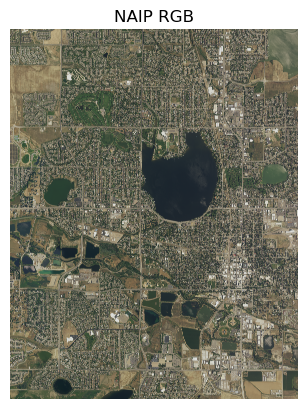

In [5]:
# Using Matplotlib we make a plot
# Note our orginal data needs to be converted from [Channels, Height, Width] to [Height, Width, Channels] using transpose
plt.imshow(img.transpose(1,2,0))
plt.title('NAIP RGB') # Add title
plt.axis('off') # Allow image to file the frame be remove axis

## Compute NDVI (Vegetation Index)
NAIP includes NIR band (band 4).

(-0.5, 9519.5, 12249.5, -0.5)

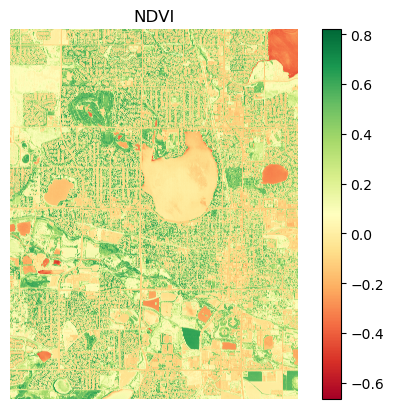

In [10]:
# Open the image storing specific bands to variables
with rasterio.open(url) as src:
    nir = src.read(4).astype(float)
    red = src.read(1).astype(float)

# Compute NDVI
ndvi = (nir - red) / (nir + red)

# show the image
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar()
plt.title('NDVI')
plt.axis('off')

Extract area of:
- Water
- Roads / Barren / Buildings
- Sparse vegetation (shrubs and grasslands or senescing crops) - approximately 0.2 to 0.5
- Dense vegetation (temperate and tropical forests or crops at their peak growth stage)  - approximately 0.6 to 0.9

Ref: https://www.usgs.gov/special-topics/remote-sensing-phenology/science/ndvi-foundation-remote-sensing-phenology

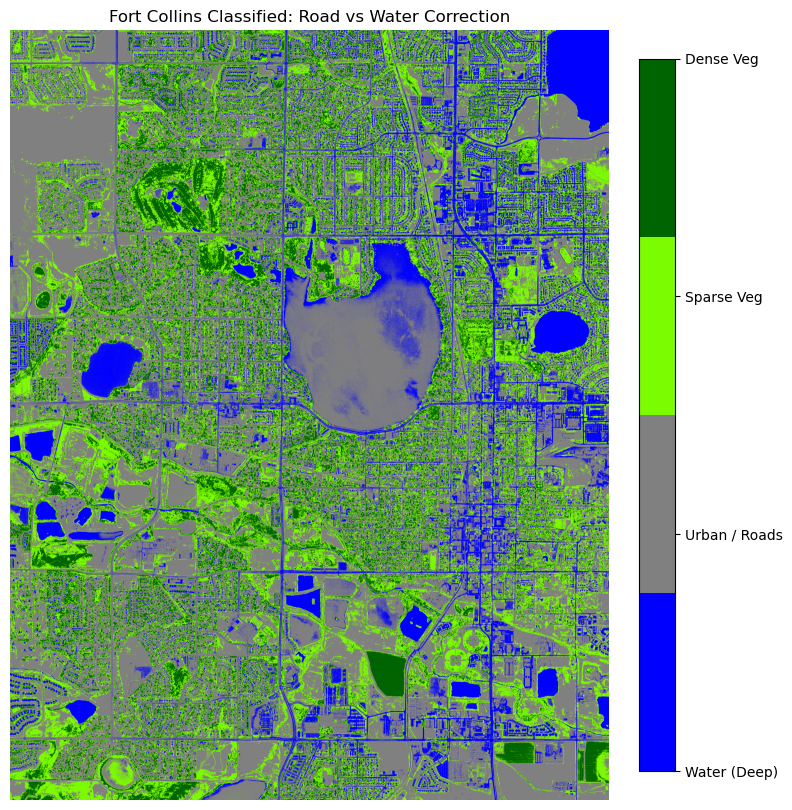

In [21]:
# 1. Redefine Bins
# Bin 0: < -0.1 (Water)
# Bin 1: -0.1 to 0.2 (Roads / Barren / Buildings)
# Bin 2: 0.2 to 0.5 (Grass / Shrubs)
# Bin 3: > 0.5 (Trees / Dense Crops)
bins = [-0.1, 0.2, 0.5] 

# 2. Assign pixels to buckets (Returns 0, 1, 2, 3)
ndvi_buckets = np.digitize(ndvi, bins)

# 3. Handle NaNs
ndvi_buckets = ndvi_buckets.astype(float)
ndvi_buckets[np.isnan(ndvi)] = np.nan

# 4. Match 4 colors to our 4 new ranges
# Blue for Water, Gray for Roads/Barren, Lawngreen for Sparse, Darkgreen for Dense
colors = ["blue", "gray", "lawngreen", "darkgreen"]
class_cmap = ListedColormap(colors)

# 5. Visualize
plt.figure(figsize=(10, 10))
# We use vmin and vmax to ensure 0 is blue and 3 is darkgreen
plt.imshow(ndvi_buckets, cmap=class_cmap, vmin=0, vmax=3)

cb = plt.colorbar(ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
cb.ax.set_yticklabels([
    "Water (Deep)", 
    "Urban / Roads", 
    "Sparse Veg", 
    "Dense Veg"
])

plt.title('Fort Collins Classified: Road vs Water Correction')
plt.axis('off')
plt.show()

# Calculate "the number of acres of each bucket

In [22]:
# Get the unique bucket values and the count of pixels in each
values, counts = np.unique(ndvi_buckets, return_counts=True)

# Remove NaNs if they exist in 'values'
mask = ~np.isnan(values)
values = values[mask]
counts = counts[mask]


# Get pixel dimensions from the transform
# transform[0] is the width of a pixel, transform[4] is the height (usually negative)
res_x = profile['transform'][0]
res_y = abs(profile['transform'][4])

pixel_area = res_x * res_y  # Area in square meters

# Create a dictionary for easy reading
bucket_names = {0: "Water", 1: "Urban / Roads", 2: "Sparse", 3: "Dense"}
area_results = {}

for val, count in zip(values, counts):
    name = bucket_names.get(val, f"Bucket {val}")
    sq_meters = count * pixel_area
    acres = sq_meters / 4046.86  # Convert to acres
    area_results[name] = acres

In [23]:
# show the results
area_results

{'Water': 1458.7584547031527,
 'Urban / Roads': 5344.579965701803,
 'Sparse': 2285.3186717603276,
 'Dense': 1285.6083877376534}